In [1]:
import sys
import os
import numpy as np
import pandas as pd
from typing import  Optional, Callable, Dict
from collections.abc import Mapping
import re, unicodedata

sys.path.append(os.path.abspath('..'))
from core.s3 import S3AssetManager

from core.viz import (
        plot_gauge_grid,
        plot_bar,
        plot_heatmap,
        plot_pie,
        plot_time_heatmap,
        plot_line,
        plot_corr_triangle
)

In [2]:
notebook_name = "aliforte_production"
s3 = S3AssetManager(notebook_name=notebook_name)

## RECATEGORIZATION

In [3]:
rename_paros = {
    # --- PRIORIDAD 1: SIN PRODUCTO (Logística/Planeación) ---
    'sin producto': 'Sin Producto',
    'sin prducto': 'Sin Producto',
    'sin producto fallo de bandas de transportador': 'Sin Producto', # Prioridad aplicada
    'sin producto y atorado de maquina': 'Sin Producto', # Prioridad aplicada
    'cambio de dado, sin producto': 'Sin Producto',
    'sin prod,cambio de dado ,saranda': 'Sin Producto',
    'limpieza de maquina y sin producto': 'Sin Producto',
    'sin producto  y tolva llena': 'Sin Producto',
    'sin producto y tolva llena': 'Sin Producto',
    'cambio de dado  ,sin producto': 'Sin Producto',
    'cambio de dado ,sin producto': 'Sin Producto',
    'sin prod  cambio de dado': 'Sin Producto',
    'Sin prod y cambio de dado ': 'Sin Producto',
    'falla del sistema /sin producto': 'Sin Producto',
    'sin producto falla dosificador de balanza': 'Sin Producto',

    # --- CAMBIO DE HERRAMENTAL (Dado/Rodillo/Saranda) ---
    'cambio de dado y saranda': 'Cambio Dado/Rodillo',
    'cambio de dado': 'Cambio Dado/Rodillo',
    'cambio de dado ': 'Cambio Dado/Rodillo',
    'Ajuste de rodillos': 'Cambio Dado/Rodillo',
    'cambio de dado,rodillos,saranda': 'Cambio Dado/Rodillo',
    'cambio de rodillos': 'Cambio Dado/Rodillo',
    'cambio de rodillo': 'Cambio Dado/Rodillo',
    'cambio de dado a nuevo /rodillos ': 'Cambio Dado/Rodillo',
    'cambio de ejes ,enrgrasado': 'Cambio Dado/Rodillo', # Mantenimiento operativo de dados/rodillos

    # --- TOLVA LLENA (Cuellos de botella) ---
    'tolva llena': 'Tolva Llena',
    'Tolva llena': 'Tolva Llena',
    'tolva llena ': 'Tolva Llena',
    'tolva granel llena ': 'Tolva Llena',
    'transp granel ocupado': 'Tolva Llena',
    'transportador ocupado': 'Tolva Llena',
    'tolva llena ,falla crambell': 'Tolva Llena',

    # --- ATASQUES (Flujo detenido) ---
    'atorado de maquina': 'Atasque',
    'atorado de maquina ': 'Atasque',
    'atorado de maq': 'Atasque',
    'atorado de maquima y acond ': 'Atasque',
    'suspendido  no pasa el producto ': 'Atasque',
    'producto no pasa ': 'Atasque',
    'producto no pasa/cambio de dado': 'Atasque',
    'atorado de cambio de tolva a granel': 'Atasque',
    'atorado de maquina/no pasa E1  ': 'Atasque',

    # --- LIMPIEZA ---
    'limpieza de peletizadora ': 'Limpieza',
    'limpieza pellet ': 'Limpieza',
    'ensacado de desinfeccion': 'Limpieza',

    # --- FALLA TRANSPORTE (Elevadores/Cintas rotas) ---
    'daño de elevador de producto terminado': 'Falla del Sistema',
    'falla del elevador ': 'Falla del Sistema',
    'falla tolva b3  puerta de apertura ': 'Falla del Sistema',

    # --- MANTENIMIENTO (Mecánico General/Varios) ---
    'mantenimiento de maquinA': 'Mantenimiento',
    'sensor de peller dañado': 'Mantenimiento',
    'mant motores ': 'Mantenimiento',
    'falla de cosedora': 'Mantenimiento',
    'tolva llena reparacion de banda ': 'Mantenimiento', # Es reparación (prioridad sobre tolva llena)
    'ensacado de producto en pelet/harina': 'Mantenimiento',
    'instalacion pelet3': 'Mantenimiento', # Instalación/Upgrade
    '*': 'Mantenimiento',

    # --- FALLA CALDERO / VAPOR ---
    'falla del Calderó': 'Falla Caldero',
    'falla del caldero mantenimiento ': 'Falla Caldero',
    'Falla de caldero': 'Falla Caldero',
    'falla de caldero': 'Falla Caldero',
    'falla de caldero ': 'Falla Caldero',
    'falla de cadero': 'Falla Caldero', # Typo corregido
    'mant. caldero': 'Falla Caldero',
    'sin vapor': 'Falla Caldero',
    'sin vapor ': 'Falla Caldero',

    # --- FALLA SISTEMA ---
    'Falla del sistema': 'Falla del Sistema',
    'falla del sistema': 'Falla del Sistema',
    'falla del sistema ': 'Falla del Sistema',

    # --- FALLA ELECTRICA ---
    'sin luz': 'Falla Electrica',
    'sin luz ': 'Falla Electrica',
    'falla pellet fusibles rotos': 'Falla Electrica',

    # --- FALLA VENTILADOR ---
    'cambio bandas ventilador': 'Falla del Sistema',
    'falla  ventilador ': 'Falla del Sistema',

    # --- EXPERIMENTAL / CALIDAD ---
    'EXP T1': 'Experimental',
    'EXP T2': 'Experimental',
    'EXP T3': 'Experimental',
    'prod por comfirmar ': 'Experimental' # Pausa por validación de calidad
}
map_tipo_actividad = {
    # --- IMPRODUCTIVO ---
    "Sin Producto": "Improductivo",
    "Atasque": "Improductivo",
    "Tolva Llena": "Improductivo",
    "Falla Caldero": "Improductivo",   # Se considera falta de suministro (vapor)
    "Falla del Sistema": "Improductivo",
    "Falla Electrica": "Improductivo",   # Se considera falta de suministro (energía)

    # --- MANTENIMIENTO ---
    "Cambio Dado/Rodillo": "Mantenimiento",
    "Limpieza": "Mantenimiento",
    "Mantenimiento": "Mantenimiento",
    "Falla Ventilador": "Mantenimiento", # Falla mecánica de componente interno

    # --- AGENTE EXTERNO ---
    "Falla Transporte": "Agente Externo",

    # --- CALIDAD ---
    "Experimental": "Calidad"
}

alimento_a_especie = {
    "G5PR": "ganaderia",
    "F-2 PREMEX": "cerdos",
    "F-3 PREMEX": "cerdos",
    "F-3": "cerdos",
    "F-4": "cerdos",
    "F-5": "cerdos",
    "F4 PREMEX": "cerdos",
    "F5": "cerdos",
    "F5 PREMEX": "cerdos",
    "F1 PREMEX": "cerdos",
    "F2 PREMEX": "cerdos",
    "F3 PREMEX": "cerdos",
    "P-2": "cerdos",
    "P-3": "cerdos",
    "P-5": "cerdos",
    "P2": "cerdos",
    "P3": "cerdos",
    "P4": "cerdos",
    "P5": "cerdos",
    "P6": "cerdos",
    "C-1": "cerdos",
    "CE1": "cerdos",
    "CE-1": "cerdos",
    "CR-2": "cerdos",
    "CR2": "cerdos",
    "CF": "cerdos",
    "CG1": "cerdos",
    "AIP": "ponedora",
    "AIP -PREMEX": "ponedora",
    "APP": "ponedora",
    "BAF": "ponedora",
    "BAI": "ponedora",
    "BCE": "cerdos",
    "BCC": "cerdos",
    "BCG": "cerdos",
    "BCL": "cerdos",
    "ACP": "ponedora",
    'C-2': 'cuyes',
    'F1':"cerdos",
    'CE2':"cerdos",
    'F2':"cerdos",
    'F3':"cerdos",
    'CL':"cerdos",
    "CR1":"cerdos",
    'F4':"cerdos",

    'C1': 'cuyes',
    'F-1 PREMEX':"cerdos",
    'F-4 PREMEX':"cerdos",
    'P-4': 'cerdos',

}

def clasificar_dieta(d):
    if pd.isna(d):
        return np.nan

    s = str(d).strip().upper()
    if s == "" or "*" in s:
        return np.nan
    if s in alimento_a_especie:
        return alimento_a_especie[s]
    token = s.split()[0]

    # 2) reglas por prefijo
    if token.startswith("HY"):
        return "reproductoras"
    if token.startswith("E"):
        return "broiler"
    if token.startswith("PF"):
        return "cerdos"
    if token.startswith("PCR"):
        return "maquila"
    if token.startswith("G"):
        return "ganaderia"
    return "desconocido"



def canonize(col: str) -> str:
    s = col.strip().replace('\n', ' ')
    s = re.sub(r'\.\d+$', '', s)
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

ES2EN = {
    'fecha': 'date',
    'hora inicio': 'start_time',
    'tipo de alimento': 'feed_type',
    'lote': 'lot',
    'cant tm': 'quantity_tm',
    'temp c': 'temperature_c',
    'tiempo de para': 'downtime',
    'observaciones': 'notes',
    'hora final': 'end_time',
    'tiempo acumulado': 'accumulated_time',
    'operador': 'operator',
}


FINAL_ORDER = [
    'date','start_time','end_time','accumulated_time','downtime',
    'feed_type','lot','quantity_tm','temperature_c','operator','notes','pellet'
]

def standardize(df: pd.DataFrame, pellet_label: str) -> pd.DataFrame:
    out = df.copy()
    out['pellet'] = pellet_label
    out = out.rename(columns=lambda c: ES2EN.get(canonize(c), canonize(c)))
    cols = [c for c in FINAL_ORDER if c in out.columns]
    return out[cols]


def limpiar_fecha(s: str) -> str | None:
    if pd.isna(s):
        return None
    s = str(s).strip()
    if not s:
        return None

    # Reemplazar ':' por '/' en cosas como '30/09:2025'
    s = s.replace(":", "/")
    # Arreglar cosas tipo '30/092025' -> '30/09/2025'
    m = re.match(r"^(\d{1,2})/(\d{2})(\d{4})$", s)
    if m:
        s = f"{m.group(1)}/{m.group(2)}/{m.group(3)}"
    return s

In [4]:
def resumen_cumplimiento_rango(
    df,
    specie_col: str,
    lot_col: str,
    value_col: str,
    target_min,
    target_max,
    unit: str = "",
    dropna: bool = False,
):
    """
    Calcula cumplimiento de rango por especie para un valor (humedad, temperatura, etc.)

    Parámetros
    ----------
    df : DataFrame
    specie_col : str
        Nombre de la columna con la especie (por ejemplo 'specie').
    lot_col : str
        Nombre de la columna de lote (por ejemplo 'lot').
    value_col : str
        Nombre de la columna con el valor a evaluar (por ejemplo 'hum').
    target_min :
        Puede ser:
          - número (ej. 11.5)
          - dict {especie: min}
          - nombre de columna con el mínimo
    target_max :
        Puede ser:
          - número (ej. 12.5)
          - dict {especie: max}
          - nombre de columna con el máximo
    unit : str
        Unidad para mostrar en el rango_objetivo (ej. "%", "°C").
    dropna : bool
        Pasar a groupby(dropna=dropna). Útil si quieres ver especies NaN.

    Retorna
    -------
    DataFrame con columnas:
      specie, rango_objetivo, valor_promedio,
      cantidad_lotes, lotes_en_rango, pct_cumplimiento
    """

    dg = df.copy()

    # --- construir columnas min y max en función de los argumentos ---
    def build_target_column(source, col_name):
        # source puede ser número, dict o nombre de columna
        if isinstance(source, Mapping):
            # dict -> map por especie
            return dg[specie_col].map(source)
        elif isinstance(source, (int, float, np.floating)):
            # valor constante
            return float(source)
        elif isinstance(source, str):
            # nombre de columna ya existente
            return dg[source]
        else:
            raise ValueError(f"No sé cómo interpretar target para {col_name}: {source}")

    dg["__min"] = build_target_column(target_min, "min")
    dg["__max"] = build_target_column(target_max, "max")

    # 1) Promedio por lote y especie
    ops = (
        dg
        .groupby([specie_col, lot_col], as_index=False, dropna=dropna)
        .agg(
            valor_min=("__min", "first"),
            valor_max=("__max", "first"),
            valor_promedio=(value_col, "mean"),
        )
    )

    # 2) Lotes dentro del rango
    ops["in_range"] = ops["valor_promedio"].between(
        ops["valor_min"],
        ops["valor_max"],
        inclusive="both"
    )

    # 3) Resumen por especie
    summary = (
        ops
        .groupby(specie_col, dropna=dropna)
        .agg(
            valor_min=("valor_min", "first"),
            valor_max=("valor_max", "first"),
            valor_promedio=("valor_promedio", "mean"),
            cantidad_lotes=(lot_col, "nunique"),
            lotes_en_rango=("in_range", "sum"),
        )
        .reset_index()
    )

    # 4) Porcentaje de cumplimiento
    summary["pct_cumplimiento"] = (
        summary["lotes_en_rango"] / summary["cantidad_lotes"] * 100
    )

    # 5) Columna de texto con rango objetivo
    label_unit = f" {unit}" if unit else ""
    summary["rango_objetivo"] = (
        "("
        + summary["valor_min"].round(1).astype(str)
        + " - "
        + summary["valor_max"].round(1).astype(str)
        + ")"
        + label_unit
    )

    # 6) Ordenar columnas y redondear
    summary = summary[
        [
            specie_col,
            "rango_objetivo",
            "valor_promedio",
            "cantidad_lotes",
            "lotes_en_rango",
            "pct_cumplimiento",
        ]
    ]

    summary = summary.round(
        {
            "valor_promedio": 2,
            "pct_cumplimiento": 2,
        }
    ).sort_values("pct_cumplimiento", ascending=True)
    summary = summary.rename(columns={
        'specie': "Especie",
        'rango_objetivo': "Rango objetivo",
        'valor_promedio': "Valor promedio",
        'cantidad_lotes': "Cantidad de lotes",
        'lotes_en_rango': "Lotes en rango",
        'pct_cumplimiento': "Pct cumplimiento",

    })

    return summary


import numpy as np
from collections.abc import Mapping


def resumen_cumplimiento_rango(
    df,
    specie_col: str,
    lot_col: str,
    value_col: str,
    target_min,
    target_max,
    unit: str = "",
    dropna: bool = False,
):
    dg = df.copy()

    # --- construir columnas min y max en función de los argumentos ---
    def build_target_col(source):
        if isinstance(source, Mapping):          # dict {specie: valor}
            return dg[specie_col].map(source)
        if isinstance(source, (int, float, np.floating)):
            return float(source)                 # constante para todos
        if isinstance(source, str):              # nombre de columna
            return dg[source]
        raise ValueError(f"target debe ser número, dict o nombre de columna. Recibí: {type(source)}")

    dg["__min"] = build_target_col(target_min)
    dg["__max"] = build_target_col(target_max)

    # 1) Promedio por lote
    lot_mean = (
        dg.groupby([specie_col, lot_col], as_index=False, dropna=dropna)
          .agg(
              valor_min=("__min", "first"),
              valor_max=("__max", "first"),
              valor_promedio_lote=(value_col, "mean"),
          )
    )

    # 2) Promedio por especie
    summary = (
        lot_mean.groupby(specie_col, dropna=dropna)
                .agg(
                    valor_min=("valor_min", "first"),
                    valor_max=("valor_max", "first"),
                    valor_promedio=("valor_promedio_lote", "mean"),
                )
                .reset_index()
    )

    vp = summary["valor_promedio"].astype(float)
    vmin = summary["valor_min"].astype(float)
    vmax = summary["valor_max"].astype(float)

    # 3) Pct cumplimiento según tu regla
    pct = np.full(len(summary), 100.0, dtype=float)

    below = vp < vmin
    above = vp > vmax

    # Si está por debajo:
    # pct = 100 - (vmin - vp)/vmin * 100  == (vp/vmin)*100
    pct_below = 100 - ((vmin - vp) / vmin) * 100
    # Si está por encima:
    # pct = 100 - (vp - vmax)/vmax * 100
    pct_above = 100 - ((vp - vmax) / vmax) * 100

    # Evitar división por 0 si min o max fueran 0
    pct_below = np.where(vmin > 0, pct_below, 0.0)
    pct_above = np.where(vmax > 0, pct_above, 0.0)

    pct[below] = pct_below[below]
    pct[above] = pct_above[above]

    # Recortar 0–100 por seguridad
    pct = np.clip(pct, 0, 100)
    summary["pct_cumplimiento"] = pct

    # (opcional) distancia fuera para diagnóstico
    summary["dist_fuera"] = np.where(
        below, (vmin - vp),
        np.where(above, (vp - vmax), 0.0)
    )

    # 4) Rango objetivo formateado
    label_unit = f" {unit}" if unit else ""
    summary["rango_objetivo"] = (
        "("
        + vmin.round(2).astype(str)
        + " - "
        + vmax.round(2).astype(str)
        + ")"
        + label_unit
    )

    # 5) Renombres EXACTOS para tu cols_cump
    out = summary.rename(columns={
        specie_col: "Especie",
        "rango_objetivo": "Rango objetivo",
        "valor_promedio": "Valor promedio",
        "pct_cumplimiento": "Pct cumplimiento",
    })

    out["Valor promedio"] = out["Valor promedio"].round(2)
    out["Pct cumplimiento"] = out["Pct cumplimiento"].round(2)

    return out.sort_values("Pct cumplimiento", ascending=True)


In [5]:
def _to_timedelta_robusto(x):
    """Convierte valores tipo '45min', '45 min', '45 minutos', 'HH:MM:SS', Timedelta, etc. a pd.Timedelta."""
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, (pd.Timedelta, np.timedelta64)):
        return pd.to_timedelta(x)

    s = str(x).strip().lower()
    if s in {"", "nan", "nat", "none"}:
        return pd.NaT

    # Casos tipo "45min" / "45 min" / "45 minutos"
    m = re.fullmatch(r"(\d+(?:\.\d+)?)\s*(min|mins|min\.|minuto|minutos)$", s)
    if m:
        return pd.to_timedelta(float(m.group(1)), unit="m")

    # Casos tipo "2h" / "2 horas"
    h = re.fullmatch(r"(\d+(?:\.\d+)?)\s*(h|hr|hrs|hora|horas)$", s)
    if h:
        return pd.to_timedelta(float(h.group(1)), unit="h")

    # Intento general: "HH:MM:SS", "0 days 00:45:00", etc.
    return pd.to_timedelta(s, errors="coerce")

def join_unique(x):
    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        vals = pd.Series(x).dropna().astype(str)
        vals = vals[vals.str.strip() != ""]
        return ", ".join(sorted(vals.unique()))
    return str(x)





def canon_code(x: str) -> str:
    s = str(x).upper().strip()
    s = re.sub(r"[^A-Z0-9]", "", s)     # quita espacios/guiones
    s = s.replace("PREMEX", "")         # quita sufijo
    return s

def pellet_mm(ft, specie):
    if pd.isna(ft):
        return np.nan

    code = canon_code(ft)

    # Regla: TODO HY
    if code.startswith("HY"):
        return '1.8 mm'

    # (a) match exacto por tabla
    if code in diam_by_code:
        return diam_by_code[code]

    # (b) fallback por especie + fase numérica (E-1, F3, etc.)
    sp = str(specie).lower().strip() if pd.notna(specie) else ""
    m = re.match(r"^([A-Z]+)(\d+)$", code)  # ej: E1, F3, CE2 -> prefijo+numero
    if m:
        pref, n = m.group(1), int(m.group(2))

        if sp == "broiler" and pref == "E":
            return '2.5 mm' if n == 1 else '3.2 mm'

        if sp == "cerdos" and pref in {"F", "CE", "CG"}:
            if n == 1:
                return '2.5 mm'
            if n in {2, 3}:
                return '3.2 mm'
            if n in {4, 5}:
                return '4.5 mm'
    # TODO
    # (c) si no hay fase, pero es cerdo y es un código "de línea", pon default conservador
    if sp == "cerdos":
        return '4.5 mm'

    return np.nan

# 1) Primero tu mapeo "oficial" por código (del mensaje anterior; ajusta si ya lo tienes)
codes_18 = {"APE1", "APP", "AIP", "BAI", "PF01"}  # + TODO HY por patrón
codes_25 = {"PF02"}
codes_32 = {"APE2", "APE3", "BAF", "C1", "C2", "C3", "ACP", "PF03"}
codes_45 = {"APE4", "P2", "P3", "P4", "P5", "P6", "CF", "CR2",
            "G1", "G2", "G3", "G4", "G5", "G5PR",
            "BCC", "BCE", "BCG", "BCL", "PCR"}

diam_by_code = {}
diam_by_code.update({c: '1.8 mm' for c in codes_18})
diam_by_code.update({c: '2.5 mm' for c in codes_25})
diam_by_code.update({c: '3.2 mm' for c in codes_32})
diam_by_code.update({c: '4.5 mm' for c in codes_45})



In [6]:


# --- Helper de Tiempo (Reutilizable) ---
def _hours_to_hms_str(hours: float) -> str:
    """Convierte float de horas a 'HH:MM:SS'."""
    if hours is None or pd.isna(hours):
        return "00:00:00"
    seconds = int(round(float(hours) * 3600))
    seconds = max(seconds, 0)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def prepare_pie_data(
    df: pd.DataFrame,
    category_col: str,
    value_col: Optional[str] = None,  # Opcional si solo quieres contar eventos (frecuencia)

    # Configuración de qué métricas incluir en el cálculo y hover
    include_sum: bool = True,
    include_mean: bool = True,
    include_count: bool = True,

    # Personalización del Hover (Etiquetas y Formateadores)
    labels: Dict[str, str] = None,    # Ej: {"sum": "Tiempo Total", "count": "N eventos"}
    formatters: Dict[str, Callable] = None # Ej: {"mean": _hours_to_hms_str}
) -> pd.DataFrame:
    """
    Procesa los datos crudos, agrupa por categoría y construye un string HTML
    para el hover con las métricas deseadas.

    Args:
        labels: Diccionario para renombrar métricas en el hover ('sum', 'mean', 'count').
        formatters: Diccionario de funciones para dar formato a los números.
    Returns:
        pd.DataFrame: DataFrame con columnas ['label', 'slice_value', 'hover_html'] listo para graficar.
    """
    d = df.copy()

    # 1. Limpieza básica
    d[category_col] = d[category_col].fillna("No especificado").astype(str).str.strip()
    d = d[d[category_col] != ""]

    # 2. Definir Agregaciones
    agg_funcs = {category_col: "size"} # Siempre calculamos count ('size')

    if value_col:
        # Asegurar numérico
        d[value_col] = pd.to_numeric(d[value_col], errors="coerce").fillna(0)
        agg_funcs[value_col] = ["sum", "mean"]

    # 3. Agrupación
    grouped = d.groupby(category_col).agg(agg_funcs)

    # 4. Aplanar MultiIndex y estandarizar nombres de columnas
    if value_col:
        # Resultado ej: category_col_size, value_col_sum, value_col_mean
        grouped.columns = ["_".join(col).strip() if col[1] else col[0] for col in grouped.columns.values]

        # Mapeo a nombres estándar internos
        col_map = {
            f"{category_col}_size": "count",
            f"{value_col}_sum": "sum",
            f"{value_col}_mean": "mean"
        }
    else:
        grouped.columns = ["count"]
        col_map = {}

    grouped = grouped.rename(columns=col_map).reset_index()

    # 5. Definir el valor principal de la rebanada (slice_value)
    # Si hay value_col y pedimos suma, la torta es por suma. Si no, es por conteo.
    main_metric = "sum" if (value_col and include_sum) else "count"
    grouped["slice_value"] = grouped[main_metric]
    grouped = grouped.sort_values("slice_value", ascending=False)

    # 6. CONSTRUCCIÓN DINÁMICA DEL HOVER HTML
    # Valores por defecto
    default_labels = {"sum": "Total", "mean": "Promedio", "count": "Eventos"}
    default_labels.update(labels or {})

    default_formatters = {
        "sum": lambda x: f"{x:.2f}",
        "mean": lambda x: f"{x:.2f}",
        "count": lambda x: f"{int(x)}"
    }
    default_formatters.update(formatters or {})

    def build_hover(row):
        # Título del tooltip (la categoría)
        lines = [f"<b>{row[category_col]}</b>"]

        # Línea de Suma (si aplica)
        if value_col and include_sum:
            val_str = default_formatters["sum"](row["sum"])
            lines.append(f"{default_labels['sum']}: {val_str}")

        # Línea de Promedio (si aplica)
        if value_col and include_mean:
            val_str = default_formatters["mean"](row["mean"])
            lines.append(f"{default_labels['mean']}: {val_str}")

        # Línea de Conteo (si aplica)
        if include_count:
            val_str = default_formatters["count"](row["count"])
            lines.append(f"{default_labels['count']}: {val_str}")

        return "<br>".join(lines)

    grouped["hover_html"] = grouped.apply(build_hover, axis=1)

    # Retornamos el nombre de la categoría en una columna estándar
    grouped = grouped.rename(columns={category_col: "label"})

    return grouped
    

In [7]:
# base = ../raw/

path_base = "raw/aliforte"

reprocesos = s3.read_excel(f"{path_base}/Consolidado reprocesos.xlsx", sheet_name='Consolidado')
reprocesos = reprocesos[reprocesos["LOTE"].notnull()].copy()
reprocesos["lot"] = pd.to_numeric(reprocesos["LOTE"], errors="coerce")
reprocesos["feed_type_reprocess"] = reprocesos["CÓDIGO"].str.strip()


qa_base = s3.read_excel(
    f"{path_base}/AGOSTO HUM Y PDI.xlsx",
    sheet_name='2025',
    skiprows=4,
)
qa_sep = s3.read_excel(f"{path_base}/HUM PDI SEPTIEMBRE 2025 (1).xlsx",skiprows=4, sheet_name='2025',)
qa_oct = s3.read_excel(f"{path_base}/PDI - HUM OCT 2025 (1).xlsx",skiprows=4,  sheet_name='2025',)
qa_nov = s3.read_excel(f"{path_base}/PDI y HUMEDAD NOV 2025.xlsx",skiprows=4,  sheet_name='2025',)


prod_base = s3.read_excel(
    f"{path_base}/PRODUCTIVIDAD DE LAS PLLET.xlsx",
    sheet_name='DATOS',
    skiprows=3,
    )

prod_new = s3.read_excel(
    f"{path_base}/Procutividad Pellet_filter.xlsx",
    sheet_name='Pellet ',
    skiprows=1,
)

prod_nov  = s3.read_excel(
    f"{path_base}/Procutividad Pellet.xlsx",
    sheet_name='DATOS',
    skiprows=1,
)

In [8]:
qa = pd.concat([ qa_base,qa_sep, qa_oct, qa_nov])
rename_qa = {
    "LOTE":"lot",
    'TIPO DE PRODUCTO': 'product',
    "HUMEDAD MÁX 13%": 'hum',
    '> 85 PDI (%)': 'pdi'
}
qa_dep = qa[rename_qa.keys()].copy()
qa_dep = qa_dep.rename(columns=rename_qa)

col_qa_num = ["lot", "pdi", "hum"]
for cl_qa in col_qa_num:
    qa_dep[cl_qa] = pd.to_numeric(qa_dep[cl_qa], errors='coerce')
qa = qa_dep[qa_dep["lot"].notnull()][["lot", "product", "hum", "pdi"]]

prod = pd.concat([ prod_base,prod_new,prod_nov])
prod_pel1_cols = [
'FECHA', 'HORA INICIO', 'TIPO DE ALIMENTO', 'LOTE', 'CANT. TM',
'TEMP. °C', 'TIEMPO DE PARA', 'OBSERVACIONES', 'HORA FINAL',
'TIEMPO \nACUMULADO', 'OPERADOR',
]
prod_pel1 = prod[prod_pel1_cols].copy()
prod_pel1.loc[:, "pellet"] ="pelle 1"

prod_pel2_cols = [
'FECHA.1',
'HORA INICIO.1', 'TIPO DE ALIMENTO.1', 'LOTE.1', 'CANT. TM.1',
'TEMP. °C.1', 'TIEMPO DE PARA.1', 'OBSERVACIONES.1', 'HORA FINAL.1',
'TIEMPO \nACUMULADO.1', 'OPERADOR.1',
]
prod_pel2 = prod[prod_pel2_cols].copy()
prod_pel2.loc[:, "pellet"] ="pelle 2"

prod_pel3_cols = [
'FECHA.2',
'HORA INICIO.2', 'TIPO DE ALIMENTO.2', 'LOTE.2', 'CANT. TM.2',
'TEMP. °C.2', 'TIEMPO DE PARA.2', 'OBSERVACIONES.2', 'HORA FINAL.2',
'TIEMPO \nACUMULADO.2', 'OPERADOR.2'
]
prod_pel3 = prod[prod_pel3_cols].copy()
prod_pel3.loc[:, "pellet"] ="pelle 3"

prod_pel1_std = standardize(prod_pel1, 'pellet 1')
prod_pel2_std = standardize(prod_pel2, 'pellet 2')
prod_pel3_std = standardize(prod_pel3, 'pellet 3')


prod_pel = pd.concat([prod_pel1_std, prod_pel2_std, prod_pel3_std], ignore_index=True)
prod_pel['date'] = pd.to_datetime(prod_pel['date'],  dayfirst=True,errors='coerce')
prod_pel['month'] = prod_pel['date'].dt.month
prod_pel = prod_pel[prod_pel['date'].notnull()].copy()

prod_pel["accumulated_td"] = prod_pel["accumulated_time"].apply(_to_timedelta_robusto)
prod_pel["hour"] = prod_pel["accumulated_td"].dt.total_seconds() / 3600

prod_pel["downtime_str"] = prod_pel["downtime"].astype(str).replace({'45min': '00:45:00'})

prod_pel["downtime_td"] = pd.to_timedelta(
    prod_pel["downtime_str"].astype(str),
)
prod_pel["downtime_hour"] = prod_pel["downtime_td"].dt.total_seconds() / 3600

prod_pel["temperature_c"] = pd.to_numeric(prod_pel['temperature_c'], errors='coerce')
prod_pel["quantity_tm"] = pd.to_numeric(prod_pel['quantity_tm'], errors='coerce')

prod_pel["start_hour"] = prod_pel['date'].astype(str) + ' ' +prod_pel['start_time'].astype(str)
prod_pel["start_hour"] = pd.to_datetime(prod_pel['start_hour'], errors='coerce')
prod_pel["ts_round"] = prod_pel["start_hour"].dt.round("H")

prod_pel["normalize_notes"] = prod_pel["notes"].replace(rename_paros)
prod_pel["details_notes"] = prod_pel["normalize_notes"].map(map_tipo_actividad)
prod_pel["details_notes"] = prod_pel["details_notes"].fillna("Productivo")

prod_pel["operator"] = (
    prod_pel["operator"]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
)
prod_pel["operator"]= prod_pel["operator"].replace({
    'Jose Benacazar': 'Jose Benalcazar',
})
prod_pel["feed_type"] = prod_pel["feed_type"].str.upper()
cond_bad = prod_pel["feed_type"].isin(['*',  ' ', 'MINUTOS', np.nan])

prod_pel["feed_type"] = prod_pel["feed_type"].replace({
    "E1": "E-1", "E2": "E-2", "E3": "E-3", "E4": "E-4",
    #"G1": "G-1", "G2": "G-2", "G3": "G-3", 'G 1': "G-1",
    #'C1': "C-1", "F1": "F-1", "F2": "F-2", "F3": "F-3", 'F4': "F-4",
    #"P1": "P-1", "P2": "P-2", "P3": "P-3", 'P4': "P-4",

})
prod_pel["feed_type"] = np.where(~cond_bad, prod_pel["feed_type"], '')
prod_pel["feed_type"]  = prod_pel["feed_type"].str.strip()

prod_pel["specie"] = prod_pel["feed_type"].apply(clasificar_dieta)

prod_pel["pellet_mm"] = prod_pel.apply(
    lambda r: pellet_mm(r["feed_type"], r["specie"]),
    axis=1
)

prod_pel["lot"] = pd.to_numeric(prod_pel["lot"], errors="coerce")
ops_pel = prod_pel[prod_pel["lot"].notnull()].copy()
sin_ops_pel = prod_pel[prod_pel["lot"].isnull()].copy()
s3.save_dataframe(ops_pel, "ops_pel.csv")

/var/folders/1g/77kw2x4j5678s_87_sqc1fpc0000gp/T/ipykernel_34108/2486151610.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  prod_pel["ts_round"] = prod_pel["start_hour"].dt.round("H")


In [9]:
prod_pel.columns

Index(['date', 'start_time', 'end_time', 'accumulated_time', 'downtime',
       'feed_type', 'lot', 'quantity_tm', 'temperature_c', 'operator', 'notes',
       'pellet', 'month', 'accumulated_td', 'hour', 'downtime_str',
       'downtime_td', 'downtime_hour', 'start_hour', 'ts_round',
       'normalize_notes', 'details_notes', 'specie', 'pellet_mm'],
      dtype='object')

In [10]:
reprocesos = reprocesos[reprocesos['lot'].notnull()].copy()
reprocesos_lot = reprocesos.groupby('lot').agg(
    quantity_reprocess_kg=('CANTIDAD KILOS', 'sum'),
    feed_type_reprocess=('feed_type_reprocess', 'first'),
    responsable=('RESPONSABLE', 'first'),
    reprocess_cause=('CAUSA REPROCESO', 'first')
).reset_index()
reprocesos_lot["quantity_reprocess_tm"] = reprocesos_lot["quantity_reprocess_kg"] / 1000

In [11]:

prod_pel_group = ops_pel.groupby(["lot", "pellet"], dropna=False).agg(
date=('date', 'first'),
feed_type=('feed_type', 'first'),
specie=('specie', 'first'),
start_time=('start_time', 'first'),
quantity_tm=('quantity_tm', 'sum'),
hour=('hour', 'sum'),
temperature_c=('temperature_c', 'mean'),
rows=('pellet', 'count'),
downtime_hour=('downtime_hour', 'sum'),
notes=('normalize_notes', 'first'), # prima el primer motivo de paro
details_notes=('details_notes', 'first'),
operators=('operator', 'first'), # lotes compartidos por tuno, prima el operario incial
pellet_mm=('pellet_mm', 'first')

).reset_index()
prod_pel_group["month"] = prod_pel_group["date"].dt.month
prod_pel_group["performance"] = prod_pel_group["quantity_tm"]/prod_pel_group["hour"]
prod_pel_group["with_notes"] = np.where(prod_pel_group["notes"].isnull(), "sin paro", "con paro")

# TODO A cada op se le asignan las medidas de calidad
prod_pel_group  = pd.merge(
   prod_pel_group,
    qa, on='lot',
    how='left')

prod_pel_group["performance"] = pd.to_numeric(prod_pel_group["performance"], errors='coerce')

#TODO: producción, evitar malas marcaciones
prod_pel_group["performance"] = prod_pel_group["performance"].replace([np.inf, -np.inf], np.nan)

prod_pel_group = prod_pel_group.sort_values(["lot", "date"]).copy()
prod_pel_group["lot"] = prod_pel_group["lot"].astype(int)


# TODO: add reprocess

prod_pel_group = pd.merge(
    prod_pel_group,
    reprocesos_lot,
    on='lot',
    how='left'
)

# Todo: tirajes cortos menores o iguales a 15 ton
cond_tiro = prod_pel_group["quantity_tm"] <= 15
prod_pel_group["tiro"] = np.where(cond_tiro, "corto", "largo")

s3.save_dataframe(prod_pel_group, "aliforte_production.csv")
prod_pel_group["performance"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
722     True
723     True
724     True
725     True
726    False
Name: performance, Length: 727, dtype: bool

In [12]:
# TODO: pellet 2 con mayor densidad de lotes cera a 0Ton/h


quantiles_map = {
    "pellet 1": (0.03, 0.99),
    "pellet 3": (0.03, 0.99),
    "pellet 2": (0.07, 0.99),
}
default_q = (0.03, 0.99)


df_base = prod_pel_group.copy()
df_pos = df_base[df_base["performance"] > 0].copy()

q_by_pellet = (
    df_pos[["pellet"]]
    .drop_duplicates()
    .assign(
        q_low=lambda d: d["pellet"].map(lambda x: quantiles_map.get(x, default_q)[0]),
        q_high=lambda d: d["pellet"].map(lambda x: quantiles_map.get(x, default_q)[1]),
    )
)
bounds = []
for _, row in q_by_pellet.iterrows():
    pel = row["pellet"]
    ql = row["q_low"]
    qh = row["q_high"]

    s = df_pos.loc[df_pos["pellet"] == pel, "performance"]
    bounds.append({
        "pellet": pel,
        "p_low": float(s.quantile(ql)),
        "p_high": float(s.quantile(qh)),
        "q_low": ql,
        "q_high": qh,
    })

bounds = pd.DataFrame(bounds).set_index("pellet")


prod_pel_with_bounds = df_base.merge(
    bounds[["p_low", "p_high"]],
    left_on="pellet",
    right_index=True,
    how="left")

cond_trimmed = (
    (prod_pel_with_bounds["performance"] > 0) &
    (prod_pel_with_bounds["performance"] >= prod_pel_with_bounds["p_low"]) &
    (prod_pel_with_bounds["performance"] <= prod_pel_with_bounds["p_high"])
)

prod_pel_trimmed = prod_pel_with_bounds[cond_trimmed].copy()
conds_bad = (~cond_trimmed) & (prod_pel_with_bounds["performance"] > 0)
prod_pel_bad = prod_pel_with_bounds[conds_bad].copy()
prod_pel_bad["lot"] = pd.to_numeric(prod_pel_bad["lot"], errors="coerce").astype("Int64")
prod_pel_bad = prod_pel_bad.round(2).sort_values("performance")

# TODO: fix
prod_pel_trimmed.loc[prod_pel_trimmed["pellet"] =="pellet 1", "performance"] = prod_pel_group["performance"] + 0.069


In [13]:
prod_pel_trimmed[prod_pel_trimmed["lot"] ==30190]["performance"]

3    5.783286
Name: performance, dtype: float64

In [14]:

cls_bad_prod = [
    "date", "lot", "pellet", "feed_type",
    "quantity_tm", "hour", "performance", "temperature_c",
    "operators", "hum", "pdi",
]

rename_map_bad = {
    "date": "fecha",
    "lot": "lote",
    "pellet": "pellet",
    "feed_type": "tipo_alimento",
    "quantity_tm": "cantidad_tm",
    "hour": "hora",
    "performance": "rendimiento",
    "temperature_c": "temperatura_c",
    "operators": "operario",
    "hum": "humedad",
    "pdi": "pdi",
}

prod_pel_bad = prod_pel_bad[cls_bad_prod].rename(columns=rename_map_bad)
s3.save_dataframe(prod_pel_bad, "detalle_bad.csv")
prod_pel_bad

,fecha,lote,pellet,tipo_alimento,cantidad_tm,hora,rendimiento,temperatura_c,operario,humedad,pdi
319,2025-09-18,31406,pellet 3,BCC,1.0,1.40,0.71,75.30,Brayan Erazo,11.85,98.48
105,2025-08-15,31170,pellet 1,F1,2.0,2.25,0.89,64.60,Jose Benalcazar,9.86,99.62
321,2025-09-18,31408,pellet 2,PF02,1.0,1.08,0.92,60.10,Brayan Erazo,9.18,99.51
54,2025-08-08,31118,pellet 2,PF01,3.0,3.25,0.92,60.50,Brayan Erazo,8.82,99.07
570,2025-10-30,31676,pellet 3,E-2,13.0,14.00,0.93,81.80,Jose Cabezas,11.76,94.20
240,2025-09-03,31319,pellet 3,F-3,1.0,1.00,1.00,75.10,Johnny Tirira,10.73,99.44
242,2025-09-03,31321,pellet 1,AIP -PREMEX,5.0,4.00,1.25,74.50,Jose Benalcazar,10.64,99.16
421,2025-10-07,31518,pellet 1,E-1,5.0,3.75,1.33,79.55,Johnny Tirira,10.77,99.21
395,2025-10-01,31490,pellet 3,P6,1.0,0.75,1.33,77.90,Jose Cabezas,12.14,98.71
401,2025-10-02,31497,pellet 1,E-1,3.0,2.17,1.38,80.30,Johnny Tirira,10.62,98.82


In [15]:
bounds

,p_low,p_high,q_low,q_high
pellet,,,,
pellet 3,2.253559,7.500000,0.03,0.99
pellet 2,1.799862,10.482932,0.07,0.99
pellet 1,1.395677,7.174716,0.03,0.99


In [16]:
prod_pel_bad_group = (
    prod_pel_bad
    .groupby(["pellet"])
    .agg(
        lot=("lote", "count"),
        feed_type=("tipo_alimento", "unique"),
        performance_min=("rendimiento", "min"),
        performance_max=("rendimiento", "max"),
        performance_median=("rendimiento", "median"),
    )
    .reset_index()
)

prod_pel_bad_group = prod_pel_bad_group.rename(columns={
    "lot": "cantidad_lotes",
    "feed_type": "tipos_alimento",
    "performance_min": "rendimiento_min",
    "performance_max": "rendimiento_max",
    "performance_median": "rendimiento_mediana",
})



prod_pel_bad_group["tipos_alimento"] = prod_pel_bad_group["tipos_alimento"].apply(join_unique)

s3.save_dataframe(prod_pel_bad_group, "prod_pel_bad.csv")
prod_pel_bad_group

,pellet,cantidad_lotes,tipos_alimento,rendimiento_min,rendimiento_max,rendimiento_mediana
0,pellet 1,7,"AIP -PREMEX, BAI, E-1, F1, HY-8",0.89,8.78,1.380
1,pellet 2,18,"ACP, E-2, E-3, F1, F1 PREMEX, F2 PREMEX, PF01,...",0.92,15.48,1.710
2,pellet 3,8,"BAI, BCC, E-1, E-2, E-3, F-3, P6, PCR",0.71,12.00,1.355


In [17]:
performance_trimmed_group = prod_pel_trimmed.groupby(["pellet"]).agg(
    lotes_q =("lot", "nunique"),
    rendimiento_q=('performance', 'mean'),
).reset_index().round(1)
performance_trimmed_group

,pellet,lotes_q,rendimiento_q
0,pellet 1,128,3.0
1,pellet 2,197,4.7
2,pellet 3,213,4.8


In [18]:

prod_pel_summary = prod_pel_group.groupby(["pellet"]).agg(
    cantidad_ops=("lot", "nunique"),
    toneladas_peletizadas=("quantity_tm", "sum"),
    pdi_promedio=('pdi', 'mean'),
    temperatura_promedio=("temperature_c", "mean"),
    humedad_promedio=('hum', "mean"),
).reset_index()

prod_pel_summary["pdi_promedio"] = prod_pel_summary["pdi_promedio"].astype(float)
prod_pel_summary = prod_pel_summary.round(2)
prod_pel_summary = pd.merge(prod_pel_summary, performance_trimmed_group, on="pellet")

rename_summary = {
    "pellet": "pellet",
    "cantidad_ops": "Cantidad Lotes",
    "toneladas_peletizadas": "Toneladas Peletizadas",
    "rendimiento_q": "Rendimiento (Ton/H) (P3/P98)",
    "pdi_promedio": "PDI (%)",
    "temperatura_promedio": "Temperatura (°C)",
    "humedad_promedio": "Humedad (%)",

             }
prod_pel_summary = prod_pel_summary.rename(
    columns=rename_summary)[rename_summary.values()]
s3.save_dataframe(prod_pel_summary, "summary.csv")
prod_pel_summary

,pellet,Cantidad Lotes,Toneladas Peletizadas,Rendimiento (Ton/H) (P3/P98),PDI (%),Temperatura (°C),Humedad (%)
0,pellet 1,157,1599.0,3.0,98.21,80.35,10.46
1,pellet 2,276,3840.0,4.7,98.09,75.42,11.26
2,pellet 3,294,3818.0,4.8,97.75,78.71,11.69


In [19]:
prod_pel_group[prod_pel_group["pellet"] == 'pellet 1'].groupby(["specie", "month"]).agg(
    tons=("quantity_tm", "sum"),
    list=("feed_type","unique"))


tons                                            list
specie        month                                                       
broiler       4        3.0                                           [E-1]
              5       30.0                                           [E-1]
              8       30.0                                           [E-1]
              9       57.0                                           [E-1]
              10     133.0                                           [E-1]
              11      70.0                                           [E-1]
              12       6.0                                           [E-1]
cerdos        8       28.0                         [PF-01, PF-02, F1, C-1]
              9       30.0                                      [C-1, BCE]
cuyes         8        5.0                                           [C-2]
ganaderia     6       30.0                               [G2, G4, G5, G-1]
              8      131.0                             [G5PR, G-3, G5, G2]
              9      123.0  [G-2, G-4, G1, G-5PR K, G-3, G-5, G-1, G-5 PR]
              11      30.0                                           [G-3]
ponedora      8       50.0                                      [APP, BAI]
              9       28.0                              [AIP -PREMEX, APP]
              10     176.0                    [AIP -PREMEX, APP, BAI, AIP]
              11     161.0                                 [BAI, AIP, APP]
reproductoras 4       12.0                                    [HY-1, HY-8]
              8       47.0                       [HY-10, HY-8, HY-6, HY-1]
              9      148.0                 [HY-2, HY-10, HY-8, HY-6, HY-3]
              10     114.0                [HY-3, HY-7, HY-8, HY-11, HY-12]
              11     136.0                              [HY-3, HY-8, HY-4]
              12      21.0                        [HY-6, HY-7, HY-8, HY-1]

In [20]:

prod_pel_summary = prod_pel_group.groupby(["specie"]).agg(
    cantidad_ops=("lot", "nunique"),
    toneladas_peletizadas =("quantity_tm", "sum"),
    horas_proceso=('hour', "sum"),
    pdi_promedio=('pdi', 'mean'),
    rendimiento=("performance", "mean"),
    temperatura_promedio=("temperature_c", "mean"),
    horas_paro=("downtime_hour", "sum"),
    humedad_promedio=('hum', "mean"),
).reset_index()
prod_pel_summary["pdi_promedio"] = prod_pel_summary["pdi_promedio"].astype(float)
prod_pel_summary = prod_pel_summary.round(2)

prod_pel_summary.rename(
    columns={"pdi_promedio": "PDI (%)",
             "cantidad_ops": "Cantidad Lotes",
             "toneladas_peletizadas": "Toneladas Peletizadas",
             "horas_proceso": "Horas Proceso",
             "temperatura_promedio": "Temperatura (°C)",
             "rendimiento": "Rendimiento (Ton/H)",
             "humedad_promedio": "Humedad (%)",

             }, inplace=True)
s3.save_dataframe(prod_pel_summary, "summary_especie.csv")
prod_pel_summary

,specie,Cantidad Lotes,Toneladas Peletizadas,Horas Proceso,PDI (%),Rendimiento (Ton/H),Temperatura (°C),horas_paro,Humedad (%)
0,broiler,232,4651.0,712.45,97.48,5.03,80.51,28.63,11.68
1,cerdos,302,2827.0,588.28,98.40,4.01,75.30,22.02,11.28
2,cuyes,7,51.0,4.67,98.71,3.43,78.67,0.00,12.38
3,ganaderia,55,541.0,100.17,97.87,4.17,76.57,5.17,10.86
4,maquila,7,8.0,2.25,98.04,3.16,73.99,0.00,11.79
5,ponedora,54,667.0,231.58,98.70,2.82,78.05,6.42,11.03
6,reproductoras,62,512.0,147.18,97.18,2.88,81.18,3.87,9.97


In [21]:
group_pel_specie =prod_pel_trimmed.groupby(["pellet", "specie"]).agg(# prod_pel_group
    cantidad_ops=("lot", "nunique"),
    toneladas_peletizadas =("quantity_tm", "sum"),
    horas_proceso=('hour', "sum"),
    pdi_promedio=('pdi', 'mean'),
    rendimiento=("performance", "mean"),
    temperatura_promedio=("temperature_c", "mean"),
    horas_paro=("downtime_hour", "sum"),
    humedad_promedio=('hum', "mean"),
).reset_index()
group_pel_specie

,pellet,specie,cantidad_ops,toneladas_peletizadas,horas_proceso,pdi_promedio,rendimiento,temperatura_promedio,horas_paro,humedad_promedio
0,pellet 1,broiler,20,266.0,113.133333,98.971111,2.460276,82.484167,2.916667,10.870556
1,pellet 1,cerdos,6,56.0,17.500000,98.440000,3.247743,75.250000,0.000000,10.996667
2,pellet 1,cuyes,1,5.0,1.500000,98.840000,3.402333,77.200000,0.000000,11.760000
3,pellet 1,ganaderia,29,299.0,71.666667,97.783929,4.065414,77.881034,2.833333,10.703214
4,pellet 1,ponedora,19,276.0,125.000000,99.127895,2.355480,81.372222,1.500000,10.807368
5,pellet 1,reproductoras,53,406.0,141.600000,97.551154,2.828802,81.618239,3.866667,9.853077
6,pellet 2,broiler,97,2120.0,370.316667,97.461146,5.529819,79.497222,15.716667,11.735729
7,pellet 2,cerdos,83,700.0,175.416667,98.721728,3.956777,72.644444,6.583333,11.048072
8,pellet 2,cuyes,1,5.0,1.416667,99.030000,3.529412,74.100000,0.000000,12.280000
9,pellet 2,maquila,1,1.0,0.416667,98.580000,2.400000,78.200000,0.000000,11.200000


In [22]:

feed_type_pel23 = prod_pel_group[(prod_pel_group["pellet"].isin(['pellet 2', 'pellet 3'])) &(prod_pel_group["performance"]>0)].pivot_table(
        index='feed_type',
        columns='pellet',
        values='quantity_tm',
        observed=False

    ).dropna().reset_index()['feed_type']
cond_pels = prod_pel_group["pellet"].isin(['pellet 2', 'pellet 3'])
cond_feed =  prod_pel_group["feed_type"].isin(feed_type_pel23)

In [23]:
import numpy as np
from collections.abc import Mapping


def resumen_cumplimiento_rango(
    df,
    specie_col: str,
    lot_col: str,
    value_col: str,
    target_min,
    target_max,
    unit: str = "",
    dropna: bool = False,
):
    dg = df.copy()

    # --- construir columnas min y max en función de los argumentos ---
    def build_target_col(source):
        if isinstance(source, Mapping):          # dict {specie: valor}
            return dg[specie_col].map(source)
        if isinstance(source, (int, float, np.floating)):
            return float(source)                 # constante para todos
        if isinstance(source, str):              # nombre de columna
            return dg[source]
        raise ValueError(f"target debe ser número, dict o nombre de columna. Recibí: {type(source)}")

    dg["__min"] = build_target_col(target_min)
    dg["__max"] = build_target_col(target_max)

    # 1) Promedio por lote
    lot_mean = (
        dg.groupby([specie_col, lot_col], as_index=False, dropna=dropna)
          .agg(
              valor_min=("__min", "first"),
              valor_max=("__max", "first"),
              valor_promedio_lote=(value_col, "mean"),
          )
    )

    # 2) Promedio por especie
    summary = (
        lot_mean.groupby(specie_col, dropna=dropna)
                .agg(
                    valor_min=("valor_min", "first"),
                    valor_max=("valor_max", "first"),
                    valor_promedio=("valor_promedio_lote", "mean"),
                )
                .reset_index()
    )

    vp = summary["valor_promedio"].astype(float)
    vmin = summary["valor_min"].astype(float)
    vmax = summary["valor_max"].astype(float)

    # 3) Pct cumplimiento según tu regla
    pct = np.full(len(summary), 100.0, dtype=float)

    below = vp < vmin
    above = vp > vmax

    # Si está por debajo:
    # pct = 100 - (vmin - vp)/vmin * 100  == (vp/vmin)*100
    pct_below = 100 - ((vmin - vp) / vmin) * 100
    # Si está por encima:
    # pct = 100 - (vp - vmax)/vmax * 100
    pct_above = 100 - ((vp - vmax) / vmax) * 100

    # Evitar división por 0 si min o max fueran 0
    pct_below = np.where(vmin > 0, pct_below, 0.0)
    pct_above = np.where(vmax > 0, pct_above, 0.0)

    pct[below] = pct_below[below]
    pct[above] = pct_above[above]

    # Recortar 0–100 por seguridad
    pct = np.clip(pct, 0, 100)
    summary["pct_cumplimiento"] = pct

    # (opcional) distancia fuera para diagnóstico
    summary["dist_fuera"] = np.where(
        below, (vmin - vp),
        np.where(above, (vp - vmax), 0.0)
    )

    # 4) Rango objetivo formateado
    label_unit = f" {unit}" if unit else ""
    summary["rango_objetivo"] = (
        "("
        + vmin.round(2).astype(str)
        + " - "
        + vmax.round(2).astype(str)
        + ")"
        + label_unit
    )

    # 5) Renombres EXACTOS para tu cols_cump
    out = summary.rename(columns={
        specie_col: "Especie",
        "rango_objetivo": "Rango objetivo",
        "valor_promedio": "Valor promedio",
        "pct_cumplimiento": "Pct cumplimiento",
    })

    out["Valor promedio"] = out["Valor promedio"].round(2)
    out["Pct cumplimiento"] = out["Pct cumplimiento"].round(2)

    return out.sort_values("Pct cumplimiento", ascending=True)


In [24]:
cols_cump = [
    'Especie', 'Rango objetivo', 'Valor promedio', 'Pct cumplimiento']
summary_hum = resumen_cumplimiento_rango(
    df=prod_pel_group[prod_pel_group["performance"]>0],
    specie_col="specie",
    lot_col="lot",
    value_col="hum",
    target_min=11.5,
    target_max=12.5,
    unit="%",    # para mostrar en rango_objetivo
)
summary_hum = summary_hum[cols_cump]
s3.save_dataframe(summary_hum, "summary_hum.csv")
summary_hum

,Especie,Rango objetivo,Valor promedio,Pct cumplimiento
6,reproductoras,(11.5 - 12.5) %,9.89,86.00
3,ganaderia,(11.5 - 12.5) %,10.80,93.90
5,ponedora,(11.5 - 12.5) %,11.06,96.18
1,cerdos,(11.5 - 12.5) %,11.29,98.20
0,broiler,(11.5 - 12.5) %,11.65,100.00
2,cuyes,(11.5 - 12.5) %,12.29,100.00
4,maquila,(11.5 - 12.5) %,11.66,100.00


In [25]:
#HUM_MIN = 11.5
#HUM_MAX = 12.5

#summary_hum = resumen_cumplimiento_rango(
#    df=prod_pel_group,
#    specie_col="specie",
#    lot_col="lot",
#    value_col="hum",
#    target_min=HUM_MIN,
#    target_max=HUM_MAX,
#    unit="%"    # para mostrar en rango_objetivo
#)

#s3.save_dataframe(summary_hum, "summary_hum.csv")
#summary_hum


In [26]:
dict_temp_species_max = {
    "cerdos": 85,
    "ganaderia": 85,
    "broiler": 85,
    "reproductoras": 85,
    "cuyes": 82,
    "maquila": 85,
    "ponedora": 85

}
summary_temp = resumen_cumplimiento_rango(
    df=prod_pel_group[prod_pel_group["performance"]>0],
    specie_col="specie",
    lot_col="lot",
    value_col="temperature_c",
    target_min=60,
    target_max=dict_temp_species_max, # máximo depende de la especie
    unit="°C"
)
cols_cump = [
    'Especie', 'Rango objetivo', 'Valor promedio', 'Pct cumplimiento']

summary_temp = summary_temp[cols_cump]
s3.save_dataframe(summary_temp, "summary_temp.csv")

summary_temp

,Especie,Rango objetivo,Valor promedio,Pct cumplimiento
0,broiler,(60.0 - 85.0) °C,80.12,100.0
1,cerdos,(60.0 - 85.0) °C,75.47,100.0
2,cuyes,(60.0 - 82.0) °C,77.20,100.0
3,ganaderia,(60.0 - 85.0) °C,77.18,100.0
4,maquila,(60.0 - 85.0) °C,74.78,100.0
5,ponedora,(60.0 - 85.0) °C,77.91,100.0
6,reproductoras,(60.0 - 85.0) °C,81.56,100.0


In [27]:
#dict_temp_species_max = {
#    "cerdos": 85,
#    "ganaderia": 85,
#    "broiler": 85,
#    "reproductoras": 85,
#    "cuyes": 82,
#    "maquila": 85,
#   "ponedora": 85
#
#}
#summary_temp = resumen_cumplimiento_rango(
#    df=prod_pel_group[prod_pel_group["performance"]>0],
#    specie_col="specie",
#    lot_col="lot",
#    value_col="temperature_c",
#    target_min=60,
#    target_max=dict_temp_species_max,
#    unit="°C"
#)
#s3.save_dataframe(summary_temp, "summary_temp.csv")
#summary_temp

In [28]:
# Ejemplo 1: Temperatura con conteo de lotes
RANGE_PDI = (90, 100)
fig = plot_gauge_grid(
    df=prod_pel_group,
    group_col="pellet",
    value_col="pdi",
    target_ranges=RANGE_PDI,
    count_col="lot",  # Cuenta lotes distintos
    label_count="Lotes",
    label_metric="Cumplimiento",
    order_groups=["pellet 1", "pellet 2", "pellet 3"],
    title_prefix="PDI",
    unit="%",
)
s3.save_plotly_html(fig, "gauge_pellet_pdi.html")

fig.show()


In [29]:
pdi_bad = prod_pel_group[prod_pel_group["pdi"]<RANGE_PDI[0]][cls_bad_prod].rename(columns=rename_map_bad).round(2)
s3.save_dataframe(pdi_bad, "pdi_bad.csv")
pdi_bad

,fecha,lote,pellet,tipo_alimento,cantidad_tm,hora,rendimiento,temperatura_c,operario,humedad,pdi
412,2025-10-06,31508,pellet 1,HY-11,8.0,2.67,3.0,76.2,Johnny Tirira,10.18,89.47


In [30]:
# Ejemplo 1: Temperatura con conteo de lotes
fig = plot_gauge_grid(
    df=prod_pel_trimmed,
    group_col="pellet",
    value_col="performance",
    target_ranges={
        "pellet 1": (2, 8),
        "pellet 2": (4, 10),
        "pellet 3": (4, 10),
    },
    order_groups=["pellet 1", "pellet 2", "pellet 3"],
    label_metric="Cumplimiento",
    count_col="lot",  # Cuenta lotes distintos
    title_prefix="Rendimiento",
    unit="Ton/H",
)
s3.save_plotly_html(fig, "gauge_pellet_rend.html")
fig.show()


In [31]:
dietas_pellet = (
    prod_pel_trimmed
    .groupby(["pellet", "feed_type"], as_index=False)
    .agg(
        rendimiento=("performance", "mean"),
        quantity_tm=("quantity_tm", "sum"),
    )
)
targets = {
    "pellet 1": prod_pel_trimmed[prod_pel_trimmed["pellet"] == "pellet 1"]["performance"].mean(),
    "pellet 2":  prod_pel_trimmed[prod_pel_trimmed["pellet"] == "pellet 2"]["performance"].mean(),
    "pellet 3":  prod_pel_trimmed[prod_pel_trimmed["pellet"] == "pellet 3"]["performance"].mean(),
}

dietas_pellet["global_mean_ton_h"] = dietas_pellet["pellet"].map(targets)
cond_diet_bad_performance = dietas_pellet["rendimiento"] < dietas_pellet["global_mean_ton_h"]

min_tm = 30
cond_diet_min_ton =dietas_pellet["quantity_tm"] > min_tm
dietas_bad_performance = dietas_pellet[cond_diet_bad_performance & cond_diet_min_ton]
peores_5_por_pellet = (
    dietas_bad_performance.sort_values("rendimiento", ascending=True).groupby("pellet").head(5)
)
peores_5_por_pellet

,pellet,feed_type,rendimiento,quantity_tm,global_mean_ton_h
3,pellet 1,BAI,2.220645,80.0,3.005249
1,pellet 1,AIP -PREMEX,2.332878,79.0,3.005249
2,pellet 1,APP,2.375647,90.0,3.005249
33,pellet 2,AIP,2.384528,37.0,4.697864
7,pellet 1,E-1,2.460276,266.0,3.005249
25,pellet 1,HY-3,2.524672,40.0,3.005249
70,pellet 2,PF02,2.613913,77.0,4.697864
47,pellet 2,E-1,2.931303,88.0,4.697864
35,pellet 2,BAI,3.042754,44.0,4.697864
36,pellet 2,BCC,3.536055,48.0,4.697864


In [32]:

corporate_colors = [
        "#1A494C", "#17877D", "#94AF92", "#F6B27A", "#F18F01",
        "#E4572E", "#6C757D", "#343A40", "#A3CED0",
    ]
fig = plot_bar(
    df=peores_5_por_pellet.round(2),
    x_col="pellet",
    group_col="feed_type",
    y_col="rendimiento",
    hover_data_cols=["quantity_tm"],
    title="",
    x_title="Pellet",
    order_x=["pellet 1", "pellet 2", "pellet 3"],
    y_title="Rendimiento (Ton/H)",
    bar_colors=corporate_colors,
    compact_mode=True,
    bar_width_scale=0.7,
    cluster_width=0.5,
)
fig.show()
s3.save_plotly_html(fig, "rendimiento_pellet_especie_decil.html")



In [33]:
# Paleta corporativa
CORP_DEEP_TEAL = "#1A494C"
CORP_TEAL      = "#1C8074"
CORP_SAGE      = "#94AF92"
CORP_GRAY      = "#6B7280"
ACCENT_WARM    = "#F6B27A"

corporate_colorscale = [
    (0.00, CORP_DEEP_TEAL),
    (0.25, CORP_TEAL),
    (0.50, CORP_GRAY),      # neutral en el medio
    (0.75, CORP_SAGE),
    (1.00, ACCENT_WARM),    # contraste agradable
]
corporate_colorway = [CORP_DEEP_TEAL, CORP_TEAL, CORP_SAGE, CORP_GRAY, ACCENT_WARM]

In [34]:
prod_pel_trimmed[(prod_pel_trimmed["pellet"] == 'pellet 2') &(prod_pel_trimmed["performance"]<4.7)]["pellet_mm"].value_counts()

pellet_mm
3.2 mm    42
2.5 mm    21
4.5 mm    19
1.8 mm    12
Name: count, dtype: int64

In [35]:
prod_pel_trimmed[(prod_pel_trimmed["pellet"] == 'pellet 2') &(prod_pel_trimmed["performance"]>4.7)]["pellet_mm"].value_counts()

pellet_mm
3.2 mm    89
4.5 mm     8
2.5 mm     3
Name: count, dtype: int64

In [36]:
prod_pel_trimmed[(prod_pel_trimmed["pellet"] == 'pellet 2') &(prod_pel_trimmed["performance"]<4.7)]["feed_type"].value_counts()

feed_type
PF02          12
E-2            8
F-3 PREMEX     6
E-1            6
E-3            6
F2 PREMEX      4
PF01           4
AIP            4
F3             4
CF             3
BAI            3
P3             3
ACP            3
BCC            3
PF 03          2
F3 PREMEX      2
F2             2
P2             1
E-2 EXP T3     1
CR2            1
BAF            1
E-2 EXP T2     1
PCR            1
HY-11          1
C-1            1
F4 PREMEX      1
CE1            1
F5 PREMEX      1
BCG            1
P4             1
CE-1           1
BCE            1
F-4            1
F-5            1
CG1            1
PF03           1
CE2            1
C-2            1
Name: count, dtype: int64

In [37]:
prod_pel_trimmed

,lot,pellet,date,feed_type,specie,start_time,quantity_tm,hour,temperature_c,rows,...,hum,pdi,quantity_reprocess_kg,feed_type_reprocess,responsable,reprocess_cause,quantity_reprocess_tm,tiro,p_low,p_high
0,313,pellet 3,2025-09-10,BCE,cerdos,16:00:00,15.0,3.166667,81.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,2.253559,7.500000
1,21296,pellet 2,2025-09-01,E-1,broiler,14:00:00,30.0,5.916667,77.1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,largo,1.799862,10.482932
2,21530,pellet 3,2025-10-08,BCG,cerdos,12:00:00,5.0,0.750000,80.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,2.253559,7.500000
3,30190,pellet 1,2025-09-17,E-1,broiler,07:30:00,30.0,5.250000,84.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,largo,1.395677,7.174716
4,30431,pellet 1,2025-09-23,HY-2,reproductoras,14:25:00,2.0,1.083333,80.3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,corto,1.395677,7.174716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614,31721,pellet 1,2025-11-10,HY-3,reproductoras,08:00:00,8.0,2.150000,84.1,2,...,10.90,99.35,NaN,NaN,NaN,NaN,NaN,corto,1.395677,7.174716
615,31722,pellet 1,2025-11-10,HY-4,reproductoras,10:30:00,8.0,1.666667,84.2,2,...,10.78,99.48,NaN,NaN,NaN,NaN,NaN,corto,1.395677,7.174716
627,31737,pellet 1,2025-11-11,AIP,ponedora,07:50:00,12.0,3.416667,83.5,2,...,11.71,99.38,NaN,NaN,NaN,NaN,NaN,corto,1.395677,7.174716
631,31741,pellet 1,2025-11-11,E-1,broiler,16:15:00,20.0,4.416667,84.2,2,...,10.82,99.10,NaN,NaN,NaN,NaN,NaN,largo,1.395677,7.174716


In [38]:
prod_pel_trimmed_grouped = prod_pel_trimmed.groupby(['pellet', 'pellet_mm']).agg(
    performance=('performance', 'mean'),
    quantity_tm=('quantity_tm', 'sum'),
    hour=('hour', 'sum')
).reset_index()


In [39]:
plot_heatmap(

    df=prod_pel_trimmed_grouped,
    x_col='pellet',
    y_col='pellet_mm',
    value_col='performance',
    secondary_col='quantity_tm',
    colorscale=corporate_colorway,
     x_title="Pellet",
    y_title='Tamaño Pellet'
    
)

In [40]:
f = plot_line(
    df=prod_pel_trimmed_grouped,
    group_col='pellet',
    x_col='pellet_mm',
    y_col='performance',
    hover_data_cols=['quantity_tm'],
    title='Rendimiento por peletizadora y tamaño de pellet',
    x_title='Tamaño de pellet (mm)',
    y_title='Rendimiento (Ton/H)'
)
f.show()
s3.save_plotly_html(f, 'rendimiento_pellet_tamano_pellet.html')

In [42]:
fig = plot_heatmap(
    df=prod_pel_trimmed,

    # Ejes
    x_col="pellet",
    y_col="operators",

    # Métrica Principal (Color + Centro)
    value_col="performance",
    aggfunc="mean",
    value_unit="Ton/H",
    decimals_value=2,

    # Métrica Secundaria (Esquina)
    secondary_col="quantity_tm",
    secondary_aggfunc="sum",
    secondary_prefix="Tons: ",
    secondary_position="bottom", # La etiqueta pequeña va abajo
    show_secondary_labels=False,


    # Estética
    colorscale=corporate_colorway,
    center_font_size=16,
    secondary_font_size=10,
    title="Matriz de Rendimiento: Operario vs Pellet",
    transparent_bg=True,
     x_title="Pellet",
    y_title='Operario'
)
fig.show()
s3.save_plotly_html(fig, "heatmap_rendimiento.html")


In [43]:
ton_by_op_pellet = prod_pel_group.groupby(["pellet", "operators"]).agg(
    ton_prom=("quantity_tm", "mean"), quantity_tm=("quantity_tm", "sum")).reset_index()
ton_by_op_pellet

,pellet,operators,ton_prom,quantity_tm
0,pellet 1,Brayan Erazo,8.000000,8.0
1,pellet 1,Johnny Tirira,9.961538,518.0
2,pellet 1,Jose Benalcazar,10.450000,1045.0
3,pellet 1,Jose Cabezas,7.000000,28.0
4,pellet 2,Brayan Erazo,14.302817,2031.0
5,pellet 2,Johnny Tirira,11.900000,119.0
6,pellet 2,Jose Benalcazar,13.000000,104.0
7,pellet 2,Jose Cabezas,13.672414,1586.0
8,pellet 3,Brayan Erazo,13.621622,2016.0
9,pellet 3,Johnny Tirira,16.111111,145.0


In [44]:

fig = plot_heatmap(
    df=prod_pel_group,
    # Ejes
    x_col="pellet",
    y_col="operators",
    # Métrica Principal (Color + Centro)
    value_col="quantity_tm",
    aggfunc="sum",
    value_unit="Ton",
    decimals_value=0,

    secondary_col= 'quantity_tm',
    secondary_aggfunc= "mean",
    # Estética
    colorscale=corporate_colorway,
    center_font_size=16,
    secondary_font_size=10,
    show_secondary_labels=False,
    title="Toneladas Totales producidas por — Operario × Pellet",
    transparent_bg=True,
     x_title="Pellet",
    y_title='Operario'
)
fig.show()
s3.save_plotly_html(fig, "pellet_heatmap_ton_pel_op.html")

In [45]:
df1 = prod_pel_trimmed[(prod_pel_trimmed["pellet"].isin(["pellet 1"]))].copy()
df1_grouped = df1.groupby(["feed_type", "pellet"]).agg(
    performance=("performance", "mean"),
    quantity_tm=("quantity_tm", "sum"),
    ).reset_index()
df1_grouped = df1_grouped[df1_grouped["quantity_tm"] > 20]
df1_grouped.sort_values(by="performance", inplace=True)

fig_1 = plot_heatmap(
    df=df1_grouped,
    x_col="feed_type",
    y_col="pellet",
    x_order=df1_grouped["feed_type"],
    value_col="performance",
    show_secondary_labels=False,
    title="Rendimiento (Ton/H) por — Dieta × Pellet",
    width=1100, height=250,
    colorscale=corporate_colorscale,
     x_title="Dieta",
    y_title='Pellet'
)
fig_1.show()
s3.save_plotly_html(fig_1, "pellet_heatmap_rendimiento_pellet1.html")



In [46]:
plot_heatmap

<function core.viz.plot_heatmap(df: pandas.core.frame.DataFrame, x_col: str, y_col: str, value_col: str, secondary_col: Optional[str] = None, secondary_aggfunc: str = 'sum', secondary_unit: str = '', secondary_unit_position: str = 'suffix', aggfunc: str = 'mean', x_order: Optional[List[str]] = None, y_order: Optional[List[str]] = None, x_title: Optional[str] = None, y_title: Optional[str] = None, value_unit: str = '', unit_position: str = 'suffix', decimals_value: int = 2, decimals_secondary: int = 1, secondary_prefix: str = '', colorscale: Union[str, List[Tuple[float, str]]] = ['#1C8074', '#666666', '#E4572E', '#29B6F6', '#FFA726'], zmin: Optional[float] = None, zmax: Optional[float] = None, zmid: Optional[float] = None, title: str = '', show_secondary_labels: bool = True, secondary_position: str = 'bottom', font_color: str = 'black', center_font_size: int = 14, secondary_font_size: int = 10, width: int = 800, height: int = 500, transparent_bg: bool = True, output_path: Optional[str] 

In [47]:
df23 = prod_pel_trimmed[prod_pel_trimmed["pellet"].isin(["pellet 2", "pellet 3"])].copy()

# si "tiro" no existe aún, asegúralo antes:
# df23["tiro"] = np.where(df23["quantity_tm"] <= 15, "corto", "largo")

dietas_ambas_pel_y_ambos_tiros = (
    df23.groupby("feed_type")[["pellet", "tiro"]]
       .apply(lambda g: g.drop_duplicates().shape[0])  # # de pares únicos (pellet, tiro)
       .loc[lambda s: s == 4]
       .index
       .tolist()
)

cond_pel12 = prod_pel_trimmed["pellet"].isin(["pellet 2", "pellet 3"])
cond_feed12 = prod_pel_trimmed["feed_type"].isin(dietas_ambas_pel_y_ambos_tiros)
prod_pel_trimmed12 = prod_pel_trimmed[cond_pel12 & cond_feed12]
prod_pel_trimmed12_corto = prod_pel_trimmed12[prod_pel_trimmed12["tiro"] == "corto"].copy()
prod_pel_trimmed12_corto = prod_pel_trimmed12_corto.groupby(['pellet','feed_type',]).agg(performance=('performance','mean')).reset_index()

prod_pel_trimmed12_largo = prod_pel_trimmed12[prod_pel_trimmed12["tiro"] != "corto"].copy()


In [48]:
fig_23 = plot_heatmap(
    df=prod_pel_trimmed12_corto,
    x_col="feed_type",
    y_col="pellet",
    value_col="performance",
    show_secondary_labels=False,
    title="Rendimiento (Ton/H) por — Dieta × Pellet en tirajes cortos",
    width=1100, height=350,
    colorscale=corporate_colorscale,
     x_title="Dieta",
    y_title='Pellet'
)
fig_23.show()
s3.save_plotly_html(fig_23, "pellet_heatmap_rendimiento_pellet23_corto.html")

In [49]:
fig_23 = plot_heatmap(
    df=prod_pel_trimmed12_largo,
    x_col="feed_type",
    y_col="pellet",
    value_col="performance",
    show_secondary_labels=False,
    secondary_col='quantity_tm',
    secondary_aggfunc = "mean",
    title="Rendimiento (Ton/H) por — Dieta × Pellet en tirajes largos",
    width=1100, height=350,
    colorscale=corporate_colorscale,
    x_title="Dieta",
    y_title='Pellet'

)
fig_23.show()
s3.save_plotly_html(fig_23, "pellet_heatmap_rendimiento_pellet23_largo.csv")

In [50]:

prod_pel_group_hum_group = (
    prod_pel_group[prod_pel_group["pellet"]  == "pellet 1"]
    .groupby(["pellet", "feed_type"], as_index=False)
    .agg(
        hum=("hum", "mean"),
        quantity_tm=("quantity_tm", "sum"),
    )
)
pellets = prod_pel_group_hum_group["pellet"].unique()
n_pellets = len(pellets)

df_ok = prod_pel_group_hum_group.query("quantity_tm > 15").copy()

dietas_validas = (
    df_ok.groupby("feed_type")["pellet"]
    .nunique()
    .loc[lambda s: s == n_pellets]
    .index
)

prod_pel_group_hum_group = df_ok[df_ok["feed_type"].isin(dietas_validas)].reset_index(drop=True)
prod_pel_group_hum_group["hum"] = prod_pel_group_hum_group["hum"].astype(float)
prod_pel_group_hum_group = prod_pel_group_hum_group.sort_values(by="hum")



fig_hum_1 = plot_heatmap(
    df=prod_pel_group_hum_group,
    x_col="feed_type",
    y_col="pellet",
    value_col="hum",
    show_secondary_labels=False,
    x_order=prod_pel_group_hum_group["feed_type"],
    secondary_col='quantity_tm',
    secondary_aggfunc = "mean",
    title="Humedad (%) por — Dieta × Pellet",
    width=1100, height=250,
    colorscale=corporate_colorscale,
    x_title="Dieta",

)
fig_hum_1.show()
s3.save_plotly_html(fig_hum_1, "pellet_heatmap_hum_pellet1.html")

In [51]:
prod_pel_group_hum_group = (
    prod_pel_group[cond_pels & cond_feed]
    .groupby(["pellet", "feed_type"], as_index=False)
    .agg(
        hum=("hum", "mean"),
        quantity_tm=("quantity_tm", "sum"),
    )
)
pellets = prod_pel_group_hum_group["pellet"].unique()
n_pellets = len(pellets)

df_ok = prod_pel_group_hum_group.query("quantity_tm > 15").copy()

dietas_validas = (
    df_ok.groupby("feed_type")["pellet"]
    .nunique()
    .loc[lambda s: s == n_pellets]
    .index
)

prod_pel_group_hum_group = df_ok[df_ok["feed_type"].isin(dietas_validas)].reset_index(drop=True)


fig_hum_23 = plot_heatmap(
    df=prod_pel_group_hum_group,
    x_col="feed_type",
    y_col="pellet",
    value_col="hum",
    show_secondary_labels=False,
    x_order=prod_pel_group_hum_group["feed_type"],
    secondary_col='quantity_tm',
    secondary_aggfunc = "mean",
    title="Humedad (%) por — Dieta × Pellet",
    width=1100, height=300,
    colorscale=corporate_colorscale,
    x_title="Dieta",
)
fig_hum_23.show()
s3.save_plotly_html(fig_hum_23, "pellet_heatmap_hum.html")


In [52]:
corporate_scale = [(0.0, "#17877D"), (0.5, "#FFFFFF"), (1.0, "#F6B27A")]
fig = plot_time_heatmap(
    df=prod_pel[prod_pel["downtime_hour"] > 0],
    x_col="pellet",
    y_col="normalize_notes",
    value_col="downtime_hour",
    input_unit='hours',
    title="Tiempo promedio de paros por  — Tipo × Pellet",
    colorscale=corporate_scale,
    width=1000,
    height=400,
    #output_path=f"{ROOT_IMAGEN}/pellet_heatmap_notes_time.html"
)
fig.show()
s3.save_plotly_html(fig, "pellet_heatmap_notes_time.html")



In [53]:
hour_avg_pellet = prod_pel_group[prod_pel_group["hour"] > 0]\
    .groupby(["date", "pellet"]).agg(hour=("hour", "sum")).reset_index()

hour_avg_pellet = hour_avg_pellet.groupby(["pellet"])\
    .agg(hour=("hour", "mean")).reset_index()

downtime_avg_pellet = prod_pel_group[prod_pel_group["downtime_hour"] > 0]\
    .groupby(["pellet", "date"]).agg(
        downtime_hour=("downtime_hour", "sum")
    ).reset_index()

downtime_avg_pellet = downtime_avg_pellet.groupby(["pellet"])\
    .agg(downtime_hour=("downtime_hour", "mean")).reset_index()

avg_time_pellet = pd.merge(downtime_avg_pellet, hour_avg_pellet, on=["pellet"], how="left")
avg_time_pellet["rate"] = avg_time_pellet["downtime_hour"] / avg_time_pellet["hour"]
avg_time_pellet["productive_hour"] = (
    avg_time_pellet["hour"] - avg_time_pellet["downtime_hour"]
)
avg_time_pellet["downtime_pct"] = avg_time_pellet["rate"] * 100
avg_time_pellet["productive_pct"] = 100 - avg_time_pellet["downtime_pct"]

# 1. (Opcional) Renombrar columnas para que se vean bonitas en la leyenda del gráfico
avg_time_pellet_clean = avg_time_pellet.rename(columns={
    "productive_pct": "Productivo",
    "downtime_pct": "Improductivo"
})

df_long = avg_time_pellet_clean.melt(
    id_vars=["pellet"],
    value_vars=["Productivo", "Improductivo"],
    var_name="pct_time",
    value_name="value"
)
df_long

,pellet,pct_time,value
0,pellet 1,Productivo,91.819780
1,pellet 2,Productivo,84.955054
2,pellet 3,Productivo,89.228788
3,pellet 1,Improductivo,8.180220
4,pellet 2,Improductivo,15.044946
5,pellet 3,Improductivo,10.771212


In [54]:
fig = plot_bar(
    df=df_long,
    x_col="pellet",
    group_col="pct_time",
    title="Distribución del tiempo de operación por pellet (día promedio)",
    y_col="value",
    show_delta=False,
    order_x=["pellet 1", "pellet 2", "pellet 3"],
    y_title="Tiempo Operación (%)",
    #output_path=f"{ROOT_IMAGEN}/avg_time_pellet_stack.html",

)
fig.show()
s3.save_plotly_html(fig, "avg_time_pellet_stack.html")

In [55]:
df_downtime = prepare_pie_data(
    df=prod_pel[prod_pel["downtime_hour"] > 0],
    category_col="normalize_notes",
    value_col="downtime_hour",

    # Configurar el Hover específico para Tiempos
    include_sum=True,
    include_mean=True,
    include_count=True,

    labels={
        "sum": "Tiempo Total (h)",
        "mean": "Duración Promedio",
        "count": "Eventos"
    },
    formatters={
        "mean": _hours_to_hms_str,
        "sum": lambda x: f"{x:.1f} h"
    }
)
df_downtime

,label,count,sum,mean,slice_value,hover_html
7,Sin Producto,31,27.433333,0.884946,27.433333,<b>Sin Producto</b><br>Tiempo Total (h): 27.4 ...
0,Atasque,26,21.833333,0.839744,21.833333,<b>Atasque</b><br>Tiempo Total (h): 21.8 h<br>...
5,Falla del Sistema,7,5.800000,0.828571,5.800000,<b>Falla del Sistema</b><br>Tiempo Total (h): ...
8,Tolva Llena,10,5.583333,0.558333,5.583333,<b>Tolva Llena</b><br>Tiempo Total (h): 5.6 h<...
1,Cambio Dado/Rodillo,5,5.000000,1.000000,5.000000,<b>Cambio Dado/Rodillo</b><br>Tiempo Total (h)...
4,Falla Electrica,3,4.000000,1.333333,4.000000,<b>Falla Electrica</b><br>Tiempo Total (h): 4....
3,Falla Caldero,6,3.616667,0.602778,3.616667,<b>Falla Caldero</b><br>Tiempo Total (h): 3.6 ...
2,Experimental,2,2.583333,1.291667,2.583333,<b>Experimental</b><br>Tiempo Total (h): 2.6 h...
6,No especificado,1,0.333333,0.333333,0.333333,<b>No especificado</b><br>Tiempo Total (h): 0....


In [56]:
fig = plot_pie(
    df_prepared=df_downtime,
    title="<b>Distribución Causas de Paro (Por Tiempo)</b>",
    #output_path=f"{ROOT_IMAGEN}/downtime_pie_time.html"
)
fig.show()
s3.save_plotly_html(fig, "downtime_pie_time.html")


In [57]:
prod_pel_group_paros_red = prod_pel_group.groupby(["pellet", "with_notes"]).agg(
    cantidad_ops=("lot", "nunique"), #
    toneladas_peletizadas =("quantity_tm", "sum"),
    horas_proceso=('hour', "sum"),
    temperatura_promedio=("temperature_c", "mean"),
    horas_paro=("downtime_hour", "mean"),
    humedad_promedio=('hum', "mean"),
    pdi_promedio=('pdi', 'mean'),
     rendimiento=("performance", "mean"), #
).reset_index()
prod_pel_group_paros_red

,pellet,with_notes,cantidad_ops,toneladas_peletizadas,horas_proceso,temperatura_promedio,horas_paro,humedad_promedio,pdi_promedio,rendimiento
0,pellet 1,con paro,24,368.0,122.483333,80.369444,0.595139,10.449130,98.544348,3.211147
1,pellet 1,sin paro,133,1231.0,422.500000,80.346565,0.002506,10.462154,98.147846,2.725383
2,pellet 2,con paro,27,678.0,107.550000,79.379630,1.041975,11.597037,97.826154,5.760373
3,pellet 2,sin paro,249,3162.0,546.933333,74.974201,0.000000,11.227004,98.122857,4.328485
4,pellet 3,con paro,29,526.0,88.366667,79.640476,0.805172,11.567931,98.105172,5.195094
5,pellet 3,sin paro,265,3292.0,498.750000,78.603958,0.000000,11.704411,97.712481,4.544887


In [58]:
orden_formula = ["pellet 1", "pellet 2", "pellet 3"]  # ajusta al orden que quieras

fig = plot_bar(
    prod_pel_group_paros_red,
    title="Rendimiento promedio en lotes peletizados con y sin paros por pellet",
    x_col="pellet",
    cat_base = "sin paro",
    group_col="with_notes",
    y_col="rendimiento",
    show_delta=True,
    order_x=["pellet 1", "pellet 2", "pellet 3"],
    y_title="Rendimiento (Ton/H)",
    #output_path=f"{ROOT_IMAGEN}/rendimiento_lotes_with_without_downtime.html",
)
fig.show()
s3.save_plotly_html(fig, "rendimiento_lotes_with_without_downtime.html")

In [59]:
cls_reprocess = ['operators', 'pellet']
lots_reprocess = prod_pel_group[cond_ton_reprocess & cond_ton_consistencie].copy()

NameError: name 'cond_ton_reprocess' is not defined

In [60]:

lots_reprocess["pellet_mm"] = (
    lots_reprocess["pellet_mm"]
    .astype(str)
    .str.replace(" mm", "")
    .astype(float)
)

NameError: name 'lots_reprocess' is not defined

In [129]:
prod_pel_group.columns

Index(['lot', 'pellet', 'date', 'feed_type', 'specie', 'start_time',
       'quantity_tm', 'hour', 'temperature_c', 'rows', 'downtime_hour',
       'notes', 'details_notes', 'operators', 'pellet_mm', 'month',
       'performance', 'with_notes', 'product', 'hum', 'pdi',
       'quantity_reprocess_kg', 'feed_type_reprocess', 'responsable',
       'reprocess_cause', 'quantity_reprocess_tm', 'tiro',
       'pellet_mm_measurment'],
      dtype='object')

In [130]:
plot_corr_triangle(
    df=lots_reprocess,
    value_cols=["quantity_tm", "pellet_mm", "performance", "hum", "pdi",'temperature_c', 'quantity_reprocess_tm', 'operators']
)

In [136]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparamos los datos
# Eliminamos filas con vacíos para que no falle el modelo
df_model = lots_reprocess[["quantity_tm", "pellet_mm", "performance", "temperature_c", "operators", 'quantity_reprocess_tm']].dropna()

# Convertimos la categórica 'operators' en números (One-Hot Encoding)
# Esto crea columnas tipo: operators_Juan, operators_Pedro...
X = pd.get_dummies(df_model[["quantity_tm", "pellet_mm", "performance", "temperature_c", "operators"]], drop_first=True)
y = df_model["quantity_reprocess_tm"]
df_model

,quantity_tm,pellet_mm,performance,temperature_c,operators,quantity_reprocess_tm
54,3.0,1.8,0.923077,60.5,Brayan Erazo,2.570
67,13.0,2.5,1.793103,65.5,Brayan Erazo,12.575
113,20.0,1.8,1.860465,72.8,Jose Cabezas,2.400
302,30.0,4.5,9.729730,80.4,Brayan Erazo,14.360
339,11.0,2.5,1.375000,76.5,Jose Cabezas,0.600
388,15.0,4.5,5.625000,79.8,Jose Cabezas,0.040
535,33.0,4.5,5.424658,80.2,Jose Cabezas,8.660


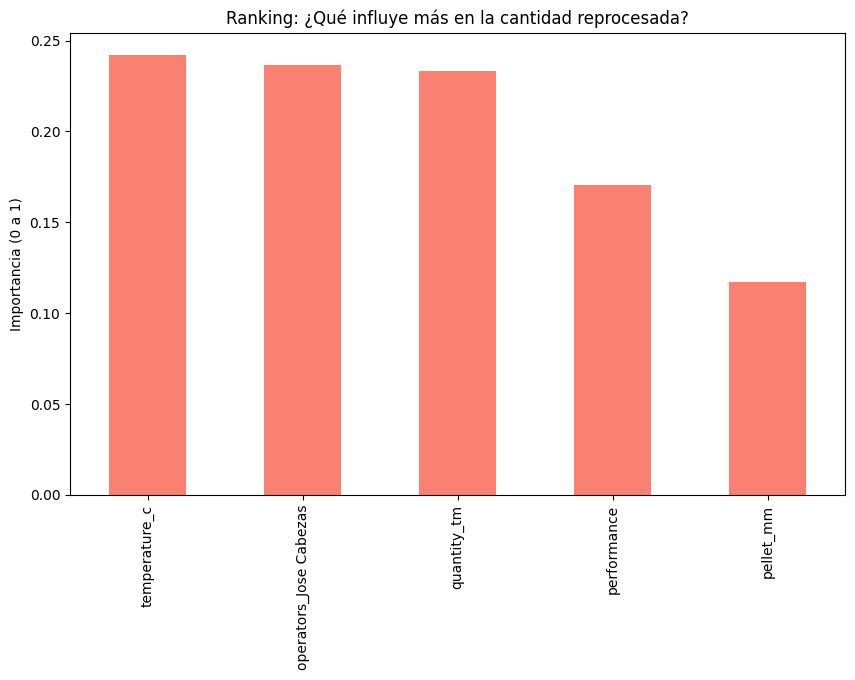

In [137]:
# 2. Entrenamos el modelo (Random Forest es excelente para esto)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extraemos la importancia
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# 4. Graficamos
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='salmon')
plt.title("Ranking: ¿Qué influye más en la cantidad reprocesada?")
plt.ylabel("Importancia (0 a 1)")
plt.show()

In [89]:
lots_reprocess.columns

Index(['lot', 'pellet', 'date', 'feed_type', 'specie', 'start_time',
       'quantity_tm', 'hour', 'temperature_c', 'rows', 'downtime_hour',
       'notes', 'details_notes', 'operators', 'pellet_mm', 'month',
       'performance', 'with_notes', 'product', 'hum', 'pdi',
       'quantity_reprocess_kg', 'feed_type_reprocess', 'responsable',
       'reprocess_cause', 'quantity_reprocess_tm', 'tiro'],
      dtype='object')

In [ ]:

group_reprocess = lots_reprocess.groupby(cls_reprocess).agg(
    count=('lot', 'count'),
    quantity_tm =('quantity_tm', 'sum'),
    quantity_reprocess_tm=('quantity_reprocess_tm', 'sum'),
    hour=('hour', 'sum'),
    performance=('performance', 'mean'),
    downtime_hour=('downtime_hour', 'sum'),
    notes=('notes', 'first'),
    pdi=('pdi', 'mean'),
    hum=('hum',  'mean')
).reset_index()
group_reprocess["pcg_reprocess"] = group_reprocess["quantity_reprocess_tm"] / group_reprocess["quantity_tm"]*100
group_reprocess

,operators,pellet,count,quantity_tm,quantity_reprocess_tm,hour,performance,downtime_hour,notes,pdi,hum,pcg_reprocess
0,Brayan Erazo,pellet 2,3,46.0,29.505,13.583333,4.148637,0.000000,None,98.563333,10.143333,64.141304
1,Brayan Erazo,pellet 3,2,16.0,2.620,0.000000,NaN,0.000000,None,98.750000,11.650000,16.375000
2,Jose Cabezas,pellet 2,1,20.0,2.400,10.750000,1.860465,0.916667,Falla Caldero,99.370000,10.930000,12.000000
3,Jose Cabezas,pellet 3,4,69.0,10.460,16.750000,4.141553,0.000000,None,98.217500,11.225000,15.159420


In [ ]:

f = plot_heatmap(

    df=group_reprocess,
    y_col='operators',
    x_col='pellet',
    value_col='quantity_reprocess_tm',
    value_unit="Ton",
    secondary_col='pcg_reprocess',
    #decimals_value=2,
    #secondary_aggfunc="sum",
    secondary_unit="%",
    secondary_unit_position='suffix',
    secondary_position="bottom",
    show_secondary_labels=True,
    title='Toneladas reprocesadas por — Operario x Pellet',
    #width=1100, height=500,
    colorscale=corporate_colorway,
    center_font_size=16,
    secondary_font_size=14,
    transparent_bg=True,
    x_title='Pellet',
    y_title='Operario'
)
f.show()
s3.save_plotly_html(f, 'reproceso_pellet.html')

In [86]:
cls_reprocess = ['pellet_mm', 'pellet']
lots_reprocess = prod_pel_group[cond_ton_reprocess & cond_ton_consistencie].copy()
group_reprocess = lots_reprocess.groupby(cls_reprocess).agg(
    count=('lot', 'count'),
    quantity_tm =('quantity_tm', 'sum'),
    quantity_reprocess_tm=('quantity_reprocess_tm', 'sum'),
    hour=('hour', 'sum'),
    performance=('performance', 'mean'),
    downtime_hour=('downtime_hour', 'sum'),
    notes=('notes', 'first'),
    pdi=('pdi', 'mean'),
    hum=('hum',  'mean')
).reset_index()
group_reprocess["pcg_reprocess"] = group_reprocess["quantity_reprocess_tm"] / group_reprocess["quantity_tm"]*100

f = plot_heatmap(

    df=group_reprocess,
    y_col='pellet_mm',
    x_col='pellet',
    value_col='quantity_reprocess_tm',
    value_unit="Ton",
    secondary_col='pcg_reprocess',
    #decimals_value=2,
    #secondary_aggfunc="sum",
    secondary_unit="%",
    secondary_unit_position='suffix',
    secondary_position="bottom",
    show_secondary_labels=True,
    title='Toneladas reprocesadas por — Tamaño Pellet x Pellet',
    #width=1100, height=500,
    colorscale=corporate_colorway,
    center_font_size=16,
    secondary_font_size=14,
    transparent_bg=True,
    x_title='Pellet',
    y_title='Tamaño Pellet'
)
f.show()
s3.save_plotly_html(f, 'reproceso_pellet_tamano_pellet.html')

In [83]:
cls_reprocess = ['feed_type', 'pellet']
lots_reprocess = prod_pel_group[cond_ton_reprocess & cond_ton_consistencie].copy()
group_reprocess = lots_reprocess.groupby(cls_reprocess).agg(
    count=('lot', 'count'),
    quantity_tm =('quantity_tm', 'sum'),
    quantity_reprocess_tm=('quantity_reprocess_tm', 'sum'),
    hour=('hour', 'sum'),
    performance=('performance', 'mean'),
    downtime_hour=('downtime_hour', 'sum'),
    notes=('notes', 'first'),
    pdi=('pdi', 'mean'),
    hum=('hum',  'mean')
).reset_index()
group_reprocess["pcg_reprocess"] = group_reprocess["quantity_reprocess_tm"] / group_reprocess["quantity_tm"]*100

f = plot_heatmap(

    df=group_reprocess,
    x_col='feed_type',
    y_col='pellet',
    value_col='quantity_reprocess_tm',
    value_unit="Ton",
    secondary_col='pcg_reprocess',
    #decimals_value=2,
    #secondary_aggfunc="sum",
    secondary_unit="%",
    secondary_unit_position='suffix',
    secondary_position="bottom",
    show_secondary_labels=True,
    title='Toneladas reprocesadas por — Operario x Pellet',
    #width=1100, height=500,
    colorscale=corporate_colorway,
    center_font_size=16,
    secondary_font_size=14,
    transparent_bg=True,
    x_title='Pellet',
    y_title='feed_type',
    width=1100, height=300,
)
f.show()
s3.save_plotly_html(f, 'reproceso_pellet_dieta.html')

In [79]:
lots_reprocess

,lot,pellet,date,feed_type,specie,start_time,quantity_tm,hour,temperature_c,rows,...,with_notes,product,hum,pdi,quantity_reprocess_kg,feed_type_reprocess,responsable,reprocess_cause,quantity_reprocess_tm,tiro
54,31118,pellet 2,2025-08-08,PF01,cerdos,18:10:00,3.0,3.250000,60.5,1,...,sin paro,PF01,8.82,99.07,2570.0,PF01,Producción,GRUMOS,2.570,corto
67,31131,pellet 2,2025-08-08,PF02,cerdos,10:10:00,13.0,7.250000,65.5,1,...,sin paro,PF02,9.83,99.58,12575.0,PF02,Jonathan Gomez,DOSIFICACION,12.575,corto
113,31178,pellet 2,2025-08-16,BAI,ponedora,09:35:00,20.0,10.750000,72.8,3,...,con paro,BAI,10.93,99.37,2400.0,BAI,José Cabezas y Bryan Erazo,GRUMOS,2.400,largo
302,31387,pellet 2,2025-09-15,CF,cerdos,13:50:00,30.0,3.083333,80.4,2,...,sin paro,CF,11.78,97.04,14360.0,CF,Ventas,CADUCADO,14.360,largo
339,31427,pellet 3,2025-09-22,E-1,broiler,14:00:00,11.0,8.000000,76.5,2,...,sin paro,APE1,11.66,98.51,600.0,APE1,José Cabezas y Bryan Erazo,QUEMADO,0.600,corto
388,31484,pellet 3,2025-09-30,G3,ganaderia,19:20:00,15.0,2.666667,79.8,1,...,sin paro,G3,9.48,97.84,40.0,G3,Ventas,MOJADO,0.040,corto
535,31642,pellet 3,2025-10-27,BCC,cerdos,19:00:00,33.0,6.083333,80.2,2,...,sin paro,BCC,11.28,98.22,8660.0,BCC,Jordan Gallegos,DOSIFICACION,8.660,largo
578,31683,pellet 3,2025-11-01,F2 PREMEX,cerdos,08:00:00,11.0,0.000000,78.5,1,...,sin paro,InF2,11.08,98.81,2000.0,InF2,Producción,PROGRAMACIÓN,2.000,corto
669,31781,pellet 3,2025-11-18,BCG,cerdos,14:50:00,5.0,0.000000,83.2,1,...,sin paro,BCG,12.22,98.69,620.0,BCG,Bryan Erazo,MEZCLADO,0.620,corto
715,31833,pellet 3,2025-11-27,P3,cerdos,17:40:00,10.0,0.000000,78.9,1,...,sin paro,P3,12.48,98.30,1160.0,P3,Producción,DOSIFICACION,1.160,corto
